In [1]:
import numpy as np
import pandas as pd
import utils
import mne
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import wilcoxon


In [2]:
# remove 5101, 541, 544 because of noisy data and 515 and 545 cause no baseline
subjects = ['485', '486', '487', '488', '489', '496', '497', '498', '499', '505', '5107', '520', '538',]
stim_side_right = ['485', '487', '489', '490', '496', '497', '5101', '5107', '515', '520', '538', '544', '545',
                       '396', '398', '404', '406', '415']
controls = ['394', '396', '398', '402', '404', '405', '406', '415', '416', '417'] 
feat_path = r'D:\Ofer_backup\V6_model\controls\p%s\unichannel_model\min_amplitude_1\features\p%s_flat_features.csv'

frontal_chans = [f"{side}{string}{number}" for string in ['OF', 'AC', 'AF', 'FA', 'IF-dAC', 'OPR'] for number in range(1, 9) for side in ['R', 'L']]
temporal_chans = [f"{string}{number}" for string in ['RA', 'LA', 'RAH', 'LAH', 'RMH', 'LMH', 'REC', 'LEC', 'RPHG', 'LPHG'] for number in range(1, 9)]
for_avg_props = {}
for_avg_props_raw = {}   # החדש – ערכים גולמיים
temporal_soz = ['485', '487', '488', '496', '497', '498', '515', '520', '544']
frontal_soz = ['486', '499', '505', '5101', '5107']
contra_stim = ['486', '487', '488', '489', '498', '499', '5101', '5107', '538', '544']
ipsi_stim = ['485', '496', '505', '515']
# curr_run_subjects = [x for x in subjects if x not in ['515', '541', '545']]
# curr_run_subjects = temporal_soz
curr_run_subjects = controls
# curr_run_subjects = controls
# curr_run_subjects = ['496']
is_control = curr_run_subjects == controls
avg_title = None
base_relative = True
box_plot = True
scaler = StandardScaler()
max_len = 10
plot_legend = ['all', 'ipsi', 'contra', 'frontal', 'temporal']


In [3]:
def get_subj_data(subj):
    df = pd.read_csv(feat_path % (subj, subj))

    # נוסיף גם timestamp + channel
    cols = ["timestamp", "channel", "amplitude", "duration", "group", "group_event_duration", "group_event_size", "group_event_deepest",
     "group_event_shallowest", "group_event_spatial_spread", "stimuli_flag", "hypnogram_flag", "angle", "relative_spike_amplitude", "relative_spike_duration"]
    df = df[cols].copy()
    df = df.drop_duplicates(subset=["group"], keep="first")

    # סינון דגימות מלוכלכות לפי קובץ הארטיפקטים של אותו נבדק
    ann_path = fr"D:\UCLA\{subj}_clean_mtl_annot.fif"
    if subj == '405':
        ann_path = fr"D:\UCLA\{subj}_clean_mtl_annot_cropped.fif"
    df = utils.remove_noisy_samples_and_channels(subj, df, ann_path, ts_col="timestamp", channel_col="channel")

    df["subject_id"] = subj
    return df

def init_dicts_with_baseline_rates(subj_features, nrem_start, stim_start, side):
    baseline_minutes = (stim_start - nrem_start) / 60
    print(baseline_minutes)
    # if there is no sleep before first stim (515, 545)
    # TODO: remove 515 and 545?! maybe avg across all
    if baseline_minutes < 0:
        # take 10 minutes before stimuli as baseline
        baseline = subj_features[(subj_features['timestamp'] > (stim_start - 10*60) * 1000) &
                                 (subj_features['timestamp'] < stim_start * 1000)]
        baseline_minutes = 10
    else:
        # take epochs after sleep onset but before first stimuli as baseline
        # baseline = subj_features[subj_features['stimuli_flag'] == 'before_first_stimuli_session']
        baseline = subj_features[(subj_features['timestamp'] < stim_start * 1000) & (subj_features['timestamp'] > nrem_start * 1000)]

    # נסדר לפי זמן כדי שה"שורה הראשונה" תהיה באמת הכי מוקדמת בזמן
    baseline = baseline.sort_values('timestamp')
    # לקחת שורה ראשונה לכל group
    baseline_groups = baseline.groupby('group', as_index=False).first()

    base_rate = len(baseline_groups) / baseline_minutes
    rates = {'all': [base_rate],
             'ipsi': [len(baseline_groups[baseline_groups['channel'].str[0] == side]) / baseline_minutes],
             'contra': [len(baseline_groups[baseline_groups['channel'].str[0] != side]) / baseline_minutes],
             'frontal': [len(baseline_groups[baseline_groups['channel'].isin(frontal_chans)]) / baseline_minutes],
             'temporal': [len(baseline_groups[baseline_groups['channel'].isin(temporal_chans)]) / baseline_minutes]}
    props = {'rates': rates}
    for prop in ['relative_spike_amplitude', 'relative_spike_duration', 'group_event_size', 'group_event_spatial_spread']:
        if 'group' in prop:
            baseline_prop = baseline_groups
        else:
            baseline_prop = baseline
        curr = {'all': [np.mean(baseline_prop[prop])],
                'ipsi': [np.mean(baseline_prop[baseline_prop['channel'].str[0] == side][prop])],
                'contra': [np.mean(baseline_prop[baseline_prop['channel'].str[0] != side][prop])],
                'frontal': [np.mean(baseline_prop[baseline_prop['channel'].isin(frontal_chans)][prop])],
                'temporal': [np.mean(baseline_prop[baseline_prop['channel'].isin(temporal_chans)][prop])]}
        props[prop] = curr

    n_chans = {'all': subj_features['channel'].nunique(),
               'ipsi': subj_features[subj_features['channel'].str[0] == side]['channel'].nunique(),
               'contra': subj_features[subj_features['channel'].str[0] != side]['channel'].nunique(),
               'frontal': subj_features[subj_features['channel'].isin(frontal_chans)]['channel'].nunique(),
               'temporal': subj_features[subj_features['channel'].isin(temporal_chans)]['channel'].nunique()}
    return props, n_chans

def append_to_props(props, curr_df, side, time):
    # rates
    groups_df = curr_df.groupby('group', as_index=False).first()
    props['rates']['all'].append(len(groups_df) / time)
    props['rates']['ipsi'].append(len(groups_df[groups_df['channel'].str[0] == side]) / time)
    props['rates']['contra'].append(len(groups_df[groups_df['channel'].str[0] != side]) / time)
    props['rates']['frontal'].append(len(groups_df[groups_df['channel'].isin(frontal_chans)]) / time)
    props['rates']['temporal'].append(len(groups_df[groups_df['channel'].isin(temporal_chans)]) / time)
    # props
    for prop in ['relative_spike_amplitude', 'relative_spike_duration', 'group_event_size',
                 'group_event_spatial_spread']:
        if 'group' in prop:
            df = groups_df
        else:
            df = curr_df
        props[prop]['all'].append(np.mean(df[prop]))
        props[prop]['ipsi'].append(np.mean(df[df['channel'].str[0] == side][prop]))
        props[prop]['contra'].append(np.mean(df[df['channel'].str[0] != side][prop]))
        props[prop]['frontal'].append(np.mean(df[df['channel'].isin(frontal_chans)][prop]))
        props[prop]['temporal'].append(np.mean(df[df['channel'].isin(temporal_chans)][prop]))


def plot_layout(subj, prop_len, prop_name, base_relative=True):
    if base_relative:
        plt.axhline(y=0, color='red', linestyle='dashed')
    for i in range(0, prop_len - 1, 2):
        plt.axvspan(i, i + 1, facecolor='silver', alpha=0.5)
    if subj in subjects:
        sleep_percent = pd.read_csv(f'results/{subj}_sleep_percent.csv')
        for k, j in enumerate(sleep_percent['sleep_percent']):
            plt.text(k - 0.7, plt.ylim()[1] -0.05, str(int(j)), size=8)
    title = f'{subj} - {prop_name} groups profile'
    if is_control:
        title = 'control - ' + title
    plt.title(title)
    plt.xlabel('Time point')
    plt.ylabel('% change from base' if base_relative else 'z-score')
    plt.legend(fontsize='small')
    plt.xlim(0, prop_len - 1)
    plt.tight_layout()
    title += '_base' if base_relative else '_z'
    plt.show()

In [4]:
# with and without norm
for subj in curr_run_subjects:
    stim_side = 'R' if subj in stim_side_right else 'L'
    final_features = get_subj_data(subj)
    if is_control:
        nrem_epochs = utils.get_control_nrem_epochs(subj)
        stim_epochs = utils.get_stim_starts_upgraded(subj)
    else:
        nrem_epochs, nrem_stim_epochs, stim_epochs = utils.get_nrem_epochs(subj)
    props, n_chans = init_dicts_with_baseline_rates(final_features, nrem_epochs[0][0], stim_epochs[0][0], stim_side)

    for i, (start, end) in enumerate(stim_epochs):
        stim_block = final_features[(final_features['timestamp'] > start * 1000) & (final_features['timestamp'] < end * 1000)]
        stim_minutes = (end - start) / 60
        append_to_props(props, stim_block, stim_side, stim_minutes)
        if i + 1 < len(stim_epochs):
            pause_block = final_features[(final_features['timestamp'] > end * 1000) & (final_features['timestamp'] < stim_epochs[i + 1][0] * 1000)]
            pause_minutes = (stim_epochs[i + 1][0] - end) / 60
            append_to_props(props, pause_block, stim_side, pause_minutes)
        else:
            # for now using only 5 minutes after last stimuli
            after = final_features[(final_features['timestamp'] > end * 1000) & (final_features['timestamp'] < (end + 60 * 5) * 1000)]
            append_to_props(props, after, stim_side, 5)

# plot the spike rate in each epoch here
    for prop in props.keys():
        if prop not in for_avg_props.keys():
            for_avg_props[prop] = {legend: [] for legend in props[prop].keys()}
        if prop not in for_avg_props_raw.keys():
            for_avg_props_raw[prop] = {legend: [] for legend in props[prop].keys()}
        for (legend, curr_rates) in props[prop].items():
            if legend in plot_legend:
                if base_relative:
                    baseline_val = curr_rates[0] if curr_rates[0] != 0 else 1e-9  # מניעת חלוקה באפס
                    norm = [(x - baseline_val) / baseline_val for x in curr_rates]
                else:
                    norm = scaler.fit_transform(np.array(curr_rates).reshape(-1,1)).flatten()
                for_avg_props[prop][legend].append(norm)
                for_avg_props_raw[prop][legend].append(curr_rates)
                if not box_plot:
                    plt.plot(norm, '-o', label=legend + ' ' + str(n_chans[legend]))

Opening raw data file D:\UCLA\394_clean_mtl_annot.fif...


C:\repos\spikes_stim\utils.py:320: RuntimeWarning: This filename (D:\UCLA\394_clean_mtl_annot.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_info = mne.io.read_raw_fif(annotations_path, preload=False)


Isotrak not found
    Range : 0 ... 29728999 =      0.000 ... 29728.999 secs
Ready.
62.0
Opening raw data file D:\UCLA\396_clean_mtl_annot.fif...
Isotrak not found


C:\repos\spikes_stim\utils.py:320: RuntimeWarning: This filename (D:\UCLA\396_clean_mtl_annot.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_info = mne.io.read_raw_fif(annotations_path, preload=False)


    Range : 0 ... 25200999 =      0.000 ... 25200.999 secs
Ready.
60.0
Opening raw data file D:\UCLA\398_clean_mtl_annot.fif...
Isotrak not found
    Range : 0 ... 18299999 =      0.000 ... 18299.999 secs
Ready.


...

Isotrak not found
    Range : 0 ... 25546999 =      0.000 ... 25546.999 secs
Ready.
Opening raw data file D:\UCLA\415_clean_mtl_annot-1.fif...
Isotrak not found
    Range : 25547000 ... 27843999 =  25547.000 ... 27843.999 secs
Ready.
165.66666666666666
Opening raw data file D:\UCLA\416_clean_mtl_annot.fif...


C:\repos\spikes_stim\utils.py:320: RuntimeWarning: This filename (D:\UCLA\416_clean_mtl_annot.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_info = mne.io.read_raw_fif(annotations_path, preload=False)


Isotrak not found
    Range : 0 ... 27542999 =      0.000 ... 27542.999 secs
Ready.
61.61666666666667
Opening raw data file D:\UCLA\417_clean_mtl_annot.fif...


C:\repos\spikes_stim\utils.py:320: RuntimeWarning: This filename (D:\UCLA\417_clean_mtl_annot.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_info = mne.io.read_raw_fif(annotations_path, preload=False)


Isotrak not found
    Range : 0 ... 31379999 =      0.000 ... 31379.999 secs
Ready.
105.5


Data points per block (after outlier removal):
[10, 8, 10, 10, 10, 9, 9, 9, 10, 10, 10, 10, 10]


C:\Users\user\AppData\Local\Temp\ipykernel_3584\1236178504.py:57: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  ax.errorbar(x_indices, mean_imm, yerr=sem_imm, zorder=4, linestyle='--',


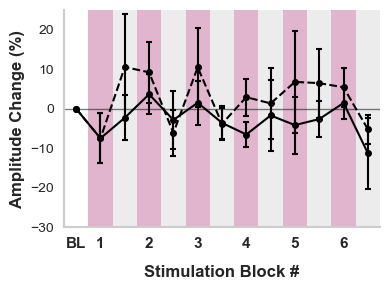

In [5]:
def get_clean_matrix(raw_data_list, mode='baseline', max_points=13, threshold=3):
    all_rows = []
    for subj_rates in raw_data_list:
        subj_rates = np.array(subj_rates)[:max_points]
        if len(subj_rates) < 2: continue
        
        if mode == 'baseline':
            b = subj_rates[0]
            if b == 0: continue
            vals = ((subj_rates - b) / b) * 100
        else: # consecutive
            prev = subj_rates[:-1]
            denom = np.where(prev == 0, 1e-9, prev)
            vals = np.insert(((subj_rates[1:] - prev) / denom) * 100, 0, 0)
        
        padded = np.full(max_points, np.nan)
        padded[:len(vals)] = vals
        all_rows.append(padded)
    
    df_wide = pd.DataFrame(all_rows)
    for col in df_wide.columns[1:]:
        q1, q3 = df_wide[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        df_wide.loc[(df_wide[col] < q1 - threshold*iqr) | (df_wide[col] > q3 + threshold*iqr), col] = np.nan
    return df_wide

# --- עיבוד נתונים ---
data_list = for_avg_props_raw['relative_spike_amplitude']['all']
df_cum = get_clean_matrix(data_list, mode='baseline')   # Cumulative
df_imm = get_clean_matrix(data_list, mode='consecutive') # Immediate

mean_cum = df_cum.mean()
sem_cum = df_cum.sem()
mean_imm = df_imm.mean()
sem_imm = df_imm.sem()
n_counts = df_cum.count() 
print("Data points per block (after outlier removal):")
print(n_counts.tolist())
x_indices = np.arange(len(mean_cum))

# --- יצירת הגרף ---
fig, ax = plt.subplots(figsize=(4, 3))

# 1. רקע צבעוני
for j in range(1, len(mean_cum)):
    color = '#ce84ad' if j % 2 != 0 else '#e0e0e0'
    ax.axvspan(j - 0.5, j + 0.5, color=color, alpha=0.6, linewidth=0)

# 2. הגדרות סטייל זהות
err_style = {'fmt': '-o', 'color': 'black', 'capsize': 2, 'markersize': 4, 
             'linewidth': 1.5, 'elinewidth': 1.5, 'capthick': 1.5}

# ציור הקווים
ax.errorbar(x_indices, mean_cum, yerr=sem_cum, zorder=5, 
            label='Cumulative Effect (vs. BL)', **err_style)

ax.errorbar(x_indices, mean_imm, yerr=sem_imm, zorder=4, linestyle='--', 
            label='Immediate Effect (Block-to-Block)', **err_style)

# 3. קו אפס
ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5, zorder=2)

# 4. עיצוב צירים ו-Ticks (העדכון שביקשת)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# הגדרת שנתות ציר Y כל 10%
# y_ticks = np.arange(-30, 25, 20) # מ-40- עד 40 (כולל) בקפיצות של 10
# ax.set_yticks(y_ticks)
# ax.set_yticklabels(y_ticks, fontsize=12) # הקטנת פונט מספרים בציר Y
ax.set_ylim(-30, 25)

# תוויות ציר X
stim_labels = ['BL'] + [str((i//2) + 1) for i in range(1, len(mean_cum), 2)]
ax.set_xticks([0] + [i for i in range(1, len(mean_cum), 2)])
ax.set_xticklabels(stim_labels, fontsize=11, fontweight='bold')

ax.set_xlabel('Stimulation Block #', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Amplitude Change (%)', fontsize=12, fontweight='bold')
ax.set_xlim(-0.5, len(mean_cum) - 0.5)
ax.grid(False)


plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_3584\4058977953.py:63: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  ax.errorbar(x_indices, mean_imm, yerr=sem_imm, zorder=4, linestyle='--',


Data points per block (after outlier removal):
[10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 9, 9, 10]


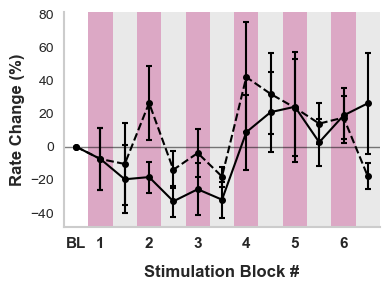

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib.patches as mpatches

def get_clean_matrix(raw_data_list, mode='baseline', max_points=13, threshold=3):
    all_rows = []
    for subj_rates in raw_data_list:
        subj_rates = np.array(subj_rates)[:max_points]
        if len(subj_rates) < 2: continue
        
        if mode == 'baseline':
            b = subj_rates[0]
            if b == 0: continue
            vals = ((subj_rates - b) / b) * 100
        else: # consecutive
            prev = subj_rates[:-1]
            denom = np.where(prev == 0, 1e-9, prev)
            vals = np.insert(((subj_rates[1:] - prev) / denom) * 100, 0, 0)
        
        padded = np.full(max_points, np.nan)
        padded[:len(vals)] = vals
        all_rows.append(padded)
    
    df_wide = pd.DataFrame(all_rows)
    for col in df_wide.columns[1:]:
        q1, q3 = df_wide[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        df_wide.loc[(df_wide[col] < q1 - threshold*iqr) | (df_wide[col] > q3 + threshold*iqr), col] = np.nan
    return df_wide

# --- עיבוד נתונים ---
data_list = for_avg_props_raw['rates']['all']
df_cum = get_clean_matrix(data_list, mode='baseline')   # Cumulative
df_imm = get_clean_matrix(data_list, mode='consecutive') # Immediate

mean_cum = df_cum.mean()
sem_cum = df_cum.sem()
mean_imm = df_imm.mean()
sem_imm = df_imm.sem()
n_counts = df_cum.count() 
print("Data points per block (after outlier removal):")
print(n_counts.tolist())
x_indices = np.arange(len(mean_cum))

# --- יצירת הגרף ---
fig, ax = plt.subplots(figsize=(4, 3))

# 1. רקע צבעוני
for j in range(1, len(mean_cum)):
    color = '#ce84ad' if j % 2 != 0 else '#e0e0e0'
    ax.axvspan(j - 0.5, j + 0.5, color=color, alpha=0.7, linewidth=0)

# 2. הגדרות סטייל זהות
err_style = {'fmt': '-o', 'color': 'black', 'capsize': 2, 'markersize': 4, 
             'linewidth': 1.5, 'elinewidth': 1.5, 'capthick': 1.5}

# ציור הקווים
ax.errorbar(x_indices, mean_cum, yerr=sem_cum, zorder=5, 
            label='Cumulative Effect (vs. BL)', **err_style)

ax.errorbar(x_indices, mean_imm, yerr=sem_imm, zorder=4, linestyle='--', 
            label='Immediate Effect (Block-to-Block)', **err_style)

# 3. קו אפס
ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5, zorder=2)

# 4. עיצוב צירים ו-Ticks (העדכון שביקשת)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# הגדרת שנתות ציר Y כל 10%
# y_ticks = np.arange(-40, 65, 20) # מ-40- עד 40 (כולל) בקפיצות של 10
# ax.set_yticks(y_ticks)
# ax.set_yticklabels(y_ticks, fontsize=12) # הקטנת פונט מספרים בציר Y
# ax.set_ylim(-45, 40)

# תוויות ציר X
stim_labels = ['BL'] + [str((i//2) + 1) for i in range(1, len(mean_cum), 2)]
ax.set_xticks([0] + [i for i in range(1, len(mean_cum), 2)])
ax.set_xticklabels(stim_labels, fontsize=11, fontweight='bold')

ax.set_xlabel('Stimulation Block #', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Rate Change (%)', fontsize=12, fontweight='bold')
ax.set_xlim(-0.5, len(mean_cum) - 0.5)
ax.grid(False)

# 5. מקרא (אופציונלי להחזיר אם תרצה)
stim_patch = mpatches.Patch(color='#8db4d3', label='Stimulation Block')
pause_patch = mpatches.Patch(color='#e0e0e0', label='Pause Block')

plt.tight_layout()
plt.show()

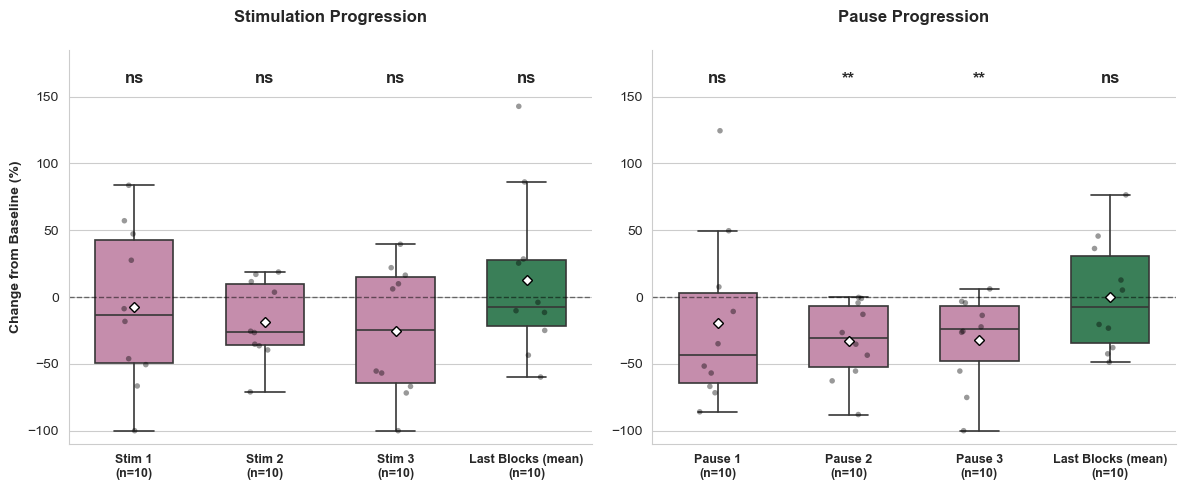

In [7]:
# 1. פונקציית עיבוד גנרית לנתונים מאוחדים (All)
def prepare_unified_data(block_type='stim'):
    all_subjects_raw_pct = []
    # שימוש בנתוני 'all' כפי שביקשת
    raw_data = for_avg_props_raw['rates']['all']
    
    for name, subj_rates in zip(controls, raw_data):        
        subj_rates = np.array(subj_rates)
        if len(subj_rates) < 3: continue
        
        baseline = subj_rates[0]
        if baseline == 0: continue
        
        # בחירת בלוקים: אי-זוגיים לגירוי, זוגיים להפסקה
        vals = subj_rates[1::2] if block_type == 'stim' else subj_rates[2::2]
        if len(vals) < 3: continue
        
        pct_changes = ((vals - baseline) / baseline) * 100
        all_subjects_raw_pct.append(pd.Series(pct_changes))
    
    df_temp = pd.DataFrame(all_subjects_raw_pct)
    
    # שלב הסינון: IQR על כל בלוק בנפרד לפני המיצוע
    for col in df_temp.columns:
        Q1, Q3 = df_temp[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        df_temp.loc[(df_temp[col] < Q1 - 3*IQR) | (df_temp[col] > Q3 + 3*IQR), col] = np.nan
        
    # בניית השלבים הסופיים
    label_prefix = 'Stim' if block_type == 'stim' else 'Pause'
    final_dict = {
        f'{label_prefix} 1': df_temp[0],
        f'{label_prefix} 2': df_temp[1],
        f'{label_prefix} 3': df_temp[2],
        'Last Blocks (mean)': df_temp.iloc[:, 3:].mean(axis=1)
    }
    
    df_wide = pd.DataFrame(final_dict)
    df_long = df_wide.melt(var_name='Stage', value_name='Change_Percent')
    return df_wide, df_long

# 2. פונקציית הציור המשותפת
def plot_combined_unified_graphs():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    sns.set_style("white")
    
    # צבעים
    stim_blue = '#ce84ad'
    pause_gray = '#ce84ad'
    last_blocks_color = '#2e8b57' # ירוק כפי שהיה בגרף המקורי שלך
    
    def draw_ax(ax, block_type):
        df_w, df_l = prepare_unified_data(block_type)
        
        # הגדרת פלטת צבעים: 3 בלוקים ראשונים בצבע המאפיין, והאחרון בירוק
        current_color = stim_blue if block_type == 'stim' else pause_gray
        pal = [current_color, current_color, current_color, last_blocks_color]
        
        # בוקספלוט
        sns.boxplot(data=df_l, x='Stage', y='Change_Percent', palette=pal,
                    width=0.6, fliersize=0, zorder=2, linewidth=1.2, ax=ax,
                    showmeans=True, meanprops={"marker":"D", "markerfacecolor":"white", 
                                               "markeredgecolor":"black", "markersize":5})
        
        # נקודות (Stripplot)
        sns.stripplot(data=df_l, x='Stage', y='Change_Percent', color='black', 
                      alpha=0.4, size=4, jitter=0.15, ax=ax, zorder=3)
        
        # סטטיסטיקה מול 0
        y_max = df_l['Change_Percent'].max()
        for i in range(df_w.shape[1]):
            data = df_w.iloc[:, i].dropna()
            if len(data) >= 5:
                _, p = wilcoxon(data)
                stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
                # הצבת הכוכביות בגובה אחיד ומעט גבוה יותר
                ax.text(i, 160, stars, ha='center', fontweight='bold', fontsize=12)

        ax.axhline(0, color='black', linestyle='--', alpha=0.5, linewidth=1)
        
        # כותרות וצירים
        title = "Stimulation Progression" if block_type == 'stim' else "Pause Progression"
        ax.set_title(title, fontsize=12, fontweight='bold', pad=20)
        ax.set_ylabel("Change from Baseline (%)" if ax == ax1 else "", fontsize=10, fontweight='bold')
        ax.set_xlabel("")
        
        # תוויות X עם n
        new_labels = [f"{col}\n(n={df_w[col].dropna().count()})" for col in df_w.columns]
        ax.set_xticklabels(new_labels, fontsize=9, fontweight='bold')
        
        # הגדרת ציר Y אחיד
        ax.set_ylim(-110, 185)
        ax.set_yticks(np.arange(-100, 151, 50))
        sns.despine(ax=ax)

    draw_ax(ax1, 'stim')
    draw_ax(ax2, 'pause')
    
    plt.tight_layout()
    plt.show()

# הרצה
plot_combined_unified_graphs()

In [8]:
for_avg_props_raw

{'rates': {'all': [[26.06451612903226,
    23.8,
    7.4,
    19.4,
    25.8,
    31.8,
    19.4,
    22.8,
    1.4,
    5.0,
    19.0,
    29.4,
    29.0,
    23.0,
    5.8,
    17.6,
    19.8],
   [4.9,
    9.0,
    11.0,
    3.6,
    3.6,
    5.2,
    5.2,
    3.2,
    6.2,
    5.6,
    4.4,
    6.8,
    3.0,
    1.4,
    2.0,
    5.0,
    3.2],
   [5.016666666666667,
    6.4,
    5.4,
    5.2,
    4.8,
    7.0,
    4.8,
    5.4,
    8.0,
    5.6,
    5.8,
    6.0,
    5.2,
    2.6,
    2.6,
    2.6,
    4.8],
   [1.6545961002785516,
    2.6,
    0.8,
    1.0,
    0.2,
    0.0,
    0.0,
    3.2,
    4.6,
    3.8,
    2.8,
    3.0,
    2.8,
    2.6,
    1.8,
    2.8,
    2.6],
   [0.926829268292683,
    0.0,
    0.4,
    0.6,
    0.6,
    0.4,
    0.8,
    2.4,
    1.8,
    3.4,
    4.6,
    4.2,
    3.4,
    3.2,
    0.0,
    0.0,
    0.2],
   [2.8315412186379927,
    1.4,
    0.4,
    1.8,
    1.6,
    0.8,
    2.2,
    1.4,
    1.8,
    1.2,
    1.2,
    2.0,
    1.8,
    1.4,
   

In [10]:
import joblib
joblib.dump(for_avg_props_raw, 'for_avg_props_raw_controls_10.pkl')

['for_avg_props_raw_controls_10.pkl']

In [13]:
(62+60+60+179.5+61.5+71.5+165.67+61.62) / 8

90.22375

In [14]:
import numpy as np

values = np.array([62, 60, 60, 179.5, 61.5, 71.5, 165.67, 61.62])

mean = np.mean(values)
sd_sample = np.std(values, ddof=1)   # sample SD
sd_population = np.std(values, ddof=0)  # population SD

print(f"Mean: {mean:.2f}")
print(f"Sample SD: {sd_sample:.2f}")
print(f"Population SD: {sd_population:.2f}")

Mean: 90.22
Sample SD: 51.10
Population SD: 47.80
